# NJ Minimum Wage Dataset
###Card & Krueger (1994) — *Minimum Wages and Employment: A Case Study of the Fast-Food Industry in New Jersey and Pennsylvania*

410 fast food restaurants surveyed in two waves, before & after NJ raised its minimum wage from \$4.25 to \$5.05 in April of 1992.

# 1. Data Import and Ingestion

## Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

## Importing the Dataset
Card & Krueger uses an ASCII file type, so headers and delimiters must be manually added.

In [2]:
# Column names in order matching public.dat layout
names = [
    'SHEET','CHAIN','CO_OWNED','STATE',                                         # Store ID, chain type, ownership, state (NJ=1, PA=0)
    'SOUTHJ','CENTRALJ','NORTHJ','PA1','PA2','SHORE',                           # Location dummies
    'NCALLS','EMPFT','EMPPT','NMGRS','WAGE_ST','INCTIME','FIRSTINC',            # Wave 1: callbacks, employment counts, wage/raise info
    'BONUS','PCTAFF','MEALS','OPEN','HRSOPEN','PSODA','PFRY','PENTREE',         # Wave 1: benefits, pricing
    'NREGS','NREGS11',                                                          # Wave 1: register counts
    'TYPE2','STATUS2','DATE2','NCALLS2','EMPFT2','EMPPT2','NMGRS2',             # Wave 2: interview type, status, date, employment
    'WAGE_ST2','INCTIME2','FIRSTIN2','SPECIAL2','MEALS2','OPEN2R','HRSOPEN2',   # Wave 2: wage/raise info, benefits
    'PSODA2','PFRY2','PENTREE2','NREGS2','NREGS112'                             # Wave 2: pricing, register counts
]

In [3]:
url = 'https://raw.githubusercontent.com/mcgeever1/card-krueger/a4919a0d2c4865d7e73941106ad02e8adce41a1b/public.dat'

In [4]:
df = pd.read_csv(url,
    sep=r'\s+',                             # Regex: split on one or more whitespace characters
    names=names,                            # Apply the names column names list
    na_values='.')                          # '.' == missing values

df # Expected: 410 obs, 46 cols

,SHEET,CHAIN,CO_OWNED,STATE,SOUTHJ,CENTRALJ,NORTHJ,PA1,PA2,SHORE,...,FIRSTIN2,SPECIAL2,MEALS2,OPEN2R,HRSOPEN2,PSODA2,PFRY2,PENTREE2,NREGS2,NREGS112
0,46,1,0,0,0,0,0,1,0,0,...,0.08,1.0,2.0,6.5,16.5,1.03,NaN,0.94,4.0,4.0
1,49,2,0,0,0,0,0,1,0,0,...,0.05,0.0,2.0,10.0,13.0,1.01,0.89,2.35,4.0,4.0
2,506,2,1,0,0,0,0,1,0,0,...,0.25,NaN,1.0,11.0,11.0,0.95,0.74,2.33,4.0,3.0
3,56,4,1,0,0,0,0,1,0,0,...,0.15,0.0,2.0,10.0,12.0,0.92,0.79,0.87,2.0,2.0
4,61,4,1,0,0,0,0,1,0,0,...,0.15,0.0,2.0,10.0,12.0,1.01,0.84,0.95,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
405,423,2,1,1,0,0,1,0,0,0,...,0.50,0.0,1.0,11.0,11.0,1.05,0.84,2.32,3.0,2.0
406,424,2,1,1,0,0,1,0,0,0,...,0.50,0.0,1.0,11.0,14.0,1.05,0.94,2.32,5.0,3.0
407,426,3,1,1,0,0,1,0,0,0,...,0.25,1.0,2.0,6.0,18.0,1.11,1.05,1.05,6.0,5.0
408,427,4,0,1,0,0,1,0,0,0,...,NaN,1.0,2.0,10.5,12.5,1.11,1.09,2.07,2.0,2.0


## Ingestion and Forensics

In [5]:
df.dtypes

SHEET         int64
CHAIN         int64
CO_OWNED      int64
STATE         int64
SOUTHJ        int64
CENTRALJ      int64
NORTHJ        int64
PA1           int64
PA2           int64
SHORE         int64
NCALLS        int64
EMPFT       float64
EMPPT       float64
NMGRS       float64
WAGE_ST     float64
INCTIME     float64
FIRSTINC    float64
BONUS         int64
PCTAFF      float64
MEALS         int64
OPEN        float64
HRSOPEN     float64
PSODA       float64
PFRY        float64
PENTREE     float64
NREGS       float64
NREGS11     float64
TYPE2         int64
STATUS2       int64
DATE2         int64
NCALLS2     float64
EMPFT2      float64
EMPPT2      float64
NMGRS2      float64
WAGE_ST2    float64
INCTIME2    float64
FIRSTIN2    float64
SPECIAL2    float64
MEALS2      float64
OPEN2R      float64
HRSOPEN2    float64
PSODA2      float64
PFRY2       float64
PENTREE2    float64
NREGS2      float64
NREGS112    float64
dtype: object

In [6]:
df.describe()

,SHEET,CHAIN,CO_OWNED,STATE,SOUTHJ,CENTRALJ,NORTHJ,PA1,PA2,SHORE,...,FIRSTIN2,SPECIAL2,MEALS2,OPEN2R,HRSOPEN2,PSODA2,PFRY2,PENTREE2,NREGS2,NREGS112
count,410.000000,410.000000,410.000000,410.000000,410.000000,410.000000,410.000000,410.000000,410.000000,410.000000,...,330.000000,392.000000,399.000000,399.000000,399.000000,388.000000,382.000000,386.000000,388.000000,383.000000
mean,246.507317,2.117073,0.343902,0.807317,0.226829,0.153659,0.426829,0.087805,0.104878,0.085366,...,0.217091,0.209184,1.776942,8.110902,14.465539,1.044948,0.941230,1.354067,3.608247,2.660574
std,148.231799,1.110497,0.475589,0.394888,0.419293,0.361062,0.495221,0.283357,0.306771,0.279767,...,0.105796,0.407246,0.547144,2.157961,2.752495,0.093567,0.109304,0.649702,1.243540,0.886009
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,8.000000,0.410000,0.690000,0.410000,1.000000,0.000000
25%,119.250000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.150000,0.000000,1.000000,7.000000,12.000000,1.000000,0.840000,0.940000,3.000000,2.000000
50%,237.500000,2.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.200000,0.000000,2.000000,7.000000,15.000000,1.050000,0.940000,1.040000,3.000000,3.000000
75%,371.750000,3.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.250000,0.000000,2.000000,10.500000,16.000000,1.102500,1.010000,2.052500,4.000000,3.000000
max,522.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,3.000000,11.500000,24.000000,1.400000,1.370000,2.850000,8.000000,7.000000


### Missing Value Strategy (MCAR vs. MAR)

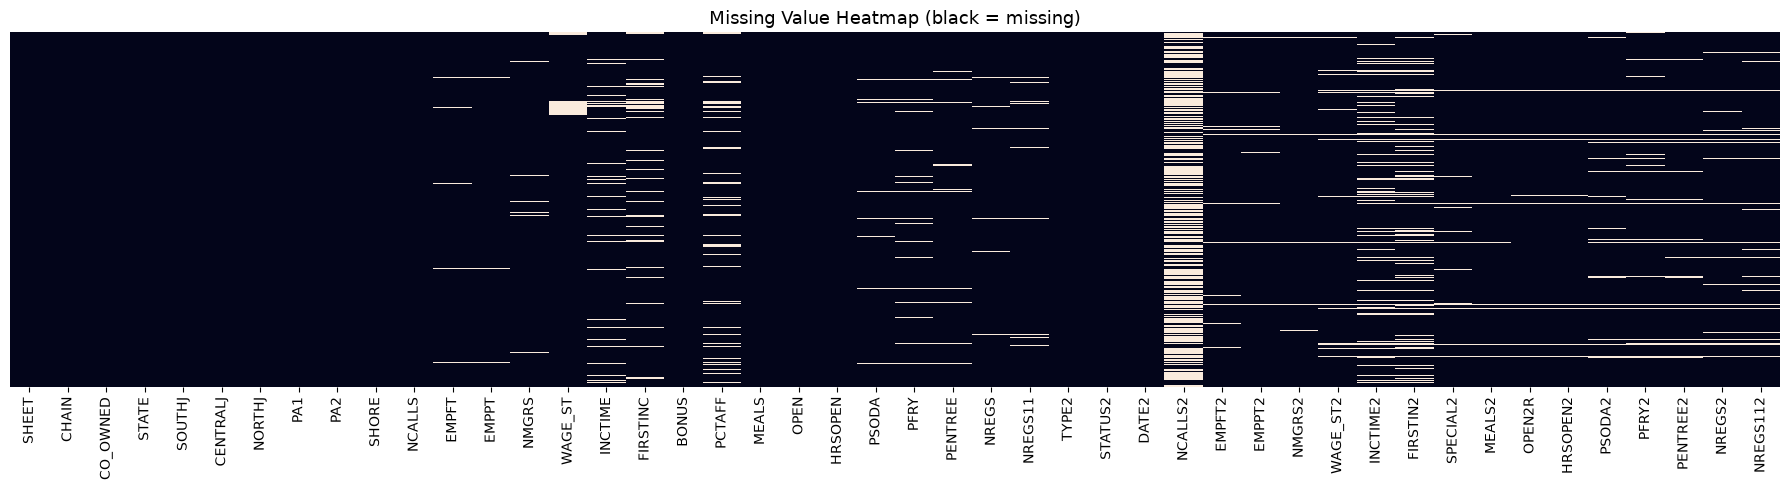

In [7]:
# Heatmap of missingness across all columns
plt.figure(figsize=(18, 5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title('Missing Value Heatmap (black = missing)', fontsize=13)
plt.tight_layout()
plt.show()

In [8]:
# Cross-tabulate STATUS2 against Wave 2 employment missingness
pd.crosstab(df['STATUS2'], df['EMPFT2'].isnull(), margins=True)

EMPFT2,False,True,All
STATUS2,,,
0,0,1,1
1,392,7,399
2,0,2,2
3,6,0,6
4,0,1,1
5,0,1,1
All,398,12,410


In [9]:
# Overall missingness rate across all columns
total_cells   = df.shape[0] * df.shape[1]
missing_cells = df.isnull().sum().sum()
print(f'Overall missingness: {missing_cells}/{total_cells} cells = {missing_cells/total_cells*100:.2f}%')

Overall missingness: 827/18860 cells = 4.38%


In [10]:
# Wave 1 vs Wave 2 column groups
wave1_cols = ['EMPFT','EMPPT','NMGRS','WAGE_ST','INCTIME','FIRSTINC','PCTAFF','OPEN','HRSOPEN','PSODA','PFRY','PENTREE']
wave2_cols = ['EMPFT2','EMPPT2','NMGRS2','WAGE_ST2','INCTIME2','FIRSTIN2','OPEN2R','HRSOPEN2','PSODA2','PFRY2','PENTREE2']

print(f'\nWave 1 missing cells: {df[wave1_cols].isnull().sum().sum()}')
print(f'Wave 2 missing cells: {df[wave2_cols].isnull().sum().sum()}')


Wave 1 missing cells: 191
Wave 2 missing cells: 291


## Sample Construction
STATUS2 == 1: answered Wave 2
STATUS2 == 3: permanently closed (FTE2 treated as 0 per C&K)

Permanently closed stores are retained with Wave 2 employment set to 0, following Card & Krueger.
A store closing is itself an employment response to the wage hike — dropping it would bias the
change-in-employment estimate. Stores that refused (STATUS2 == 0), were under renovation (2),
closed for highway construction (4), or a mall fire (5) are excluded as their status is unrelated
to the policy. Missing Wave 2 values for the remaining excluded stores are MAR, conditional on STATUS2.

In [11]:
# Keep answered + permanently closed stores
df_complete = df[df['STATUS2'].isin([1, 3])].copy()

# Permanently closed stores had zero employees in Wave 2
closed = df_complete['STATUS2'] == 3
df_complete.loc[closed, ['EMPFT2', 'EMPPT2', 'NMGRS2']] = 0

print(f'Full dataset:      {len(df)} stores')
print(f'Analysis subset:   {len(df_complete)} stores (STATUS2 == 1 or 3)')
print(f'  Answered Wave 2: {(df_complete["STATUS2"] == 1).sum()} stores')
print(f'  Permanently closed (FTE2 = 0): {closed.sum()} stores')
print(f'Excluded:          {len(df) - len(df_complete)} stores (refused / renovation / other)')

Full dataset:      410 stores
Analysis subset:   405 stores (STATUS2 == 1 or 3)
  Answered Wave 2: 399 stores
  Permanently closed (FTE2 = 0): 6 stores
Excluded:          5 stores (refused / renovation / other)


## Variable Construction

### FTE
Card & Krueger collapse three worker types into one comparable number they call Full-Time Equivalent (FTE).

Part-timers are weighted at 0.5 (they supply roughly half the labor of a full-timer). Managers are counted at 1.0 (salaried, full hours).

In [12]:
# FTE Model -- with Card & Krueger employee aggregation formula
df_complete['FTE']  = df_complete['EMPFT']  + 0.5 * df_complete['EMPPT']  + df_complete['NMGRS']
df_complete['FTE2'] = df_complete['EMPFT2'] + 0.5 * df_complete['EMPPT2'] + df_complete['NMGRS2']

### GAP
Created by Card & Krueger to measure how much each NJ store had to raise its wage to comply with the new $5.05 minimum.

Store paying $4.25 needed to raise by \$0.80 meaning the GAP = 0.80/4.25 = 0.188 (18.8%) of wage before the hike

In [13]:
# All stores initialize at 0
df_complete['GAP'] = 0.0

# NJ stores paying below the new wage update GAP
nj_below = (df_complete['STATE'] == 1) & (df_complete['WAGE_ST'] < 5.05)

df_complete.loc[nj_below, 'GAP'] = (
    (5.05 - df_complete.loc[nj_below, 'WAGE_ST']) / df_complete.loc[nj_below, 'WAGE_ST']
)

### Error Store -- SHEET 407 assigned to two different stores (one NJ, one PA)

In [14]:
# Diagnosing error store
df_complete[df_complete['SHEET'] == 407][['SHEET', 'STATE', 'FTE', 'FTE2']]

,SHEET,STATE,FTE,FTE2
41,407,0,11.0,11.0
167,407,1,12.0,14.5


In [15]:
# Drop the duplicate store
df_complete = df_complete[df_complete['SHEET'] != 407]

### Panel Stack (DiD Setup)
Each store must occupy two rows (one per wave) for the DiD regression.
POST = 0 means before treatment, POST = 1 means after treatment.

In [16]:
# Wave 1
wave1 = df_complete[['SHEET', 'STATE', 'FTE', 'CHAIN', 'CO_OWNED', 'SHORE', 'GAP']].copy()
wave1['POST'] = 0
wave1 = wave1.rename(columns={'FTE': 'fte'})

# Wave 2
wave2 = df_complete[['SHEET', 'STATE', 'FTE2', 'CHAIN', 'CO_OWNED', 'SHORE', 'GAP']].copy()
wave2['POST'] = 1
wave2 = wave2.rename(columns={'FTE2': 'fte'})

df_stacked = pd.concat([wave1, wave2], ignore_index=True)

# Verify: each store should appear exactly twice
df_stacked.groupby('SHEET').size().value_counts()

2    403
Name: count, dtype: int64

In [17]:
# Stores missing employment in either wave break the panel
missing_sheets = df_stacked.loc[df_stacked['fte'].isnull(), 'SHEET'].unique()

# Drop both rows for any store with a missing wave
df_stacked_balanced = df_stacked[~df_stacked['SHEET'].isin(missing_sheets)].copy()

print(f'Stores dropped: {len(missing_sheets)}')
print(f'Rows: {len(df_stacked_balanced)}')
print(f'Unique stores: {df_stacked_balanced["SHEET"].nunique()}')


Stores dropped: 21
Rows: 764
Unique stores: 382


### First Difference (Card & Krueger eq. 1a)
Collapse the two-row panel to one row per store, with the change in FTE as the dependent variable.
Differencing sweeps out every time-invariant store characteristic, so the DiD estimate is read
straight off the STATE coefficient. The balanced panel above defines the sample this is built from.


In [18]:
# One row per store: DFTE = FTE(Wave 2) - FTE(Wave 1)
df_fd = df_stacked_balanced.pivot(index='SHEET', columns='POST', values='fte')
df_fd.columns = ['fte_1', 'fte_2']
df_fd = df_fd.join(df_complete.set_index('SHEET')[['STATE','CHAIN','CO_OWNED','SHORE','GAP']])
df_fd['DFTE'] = df_fd['fte_2'] - df_fd['fte_1']
df_fd = df_fd.reset_index()

print(f'Stores: {len(df_fd)}')
print(f'Missing DFTE rows: {df_fd["DFTE"].isnull().sum()}')
df_fd.head()


Stores: 382
Missing DFTE rows: 0


,SHEET,fte_1,fte_2,STATE,CHAIN,CO_OWNED,SHORE,GAP,DFTE
0,1,35.0,44.0,1,1,0,0,0.122222,9.0
1,2,16.0,15.5,1,1,0,0,0.063158,-0.5
2,3,15.5,10.5,1,2,0,0,0.188235,-5.0
3,4,19.0,24.0,1,3,0,0,0.063158,5.0
4,5,24.0,29.0,1,3,0,0,0.122222,5.0


# 2. Data Description

## Univariate Distribution

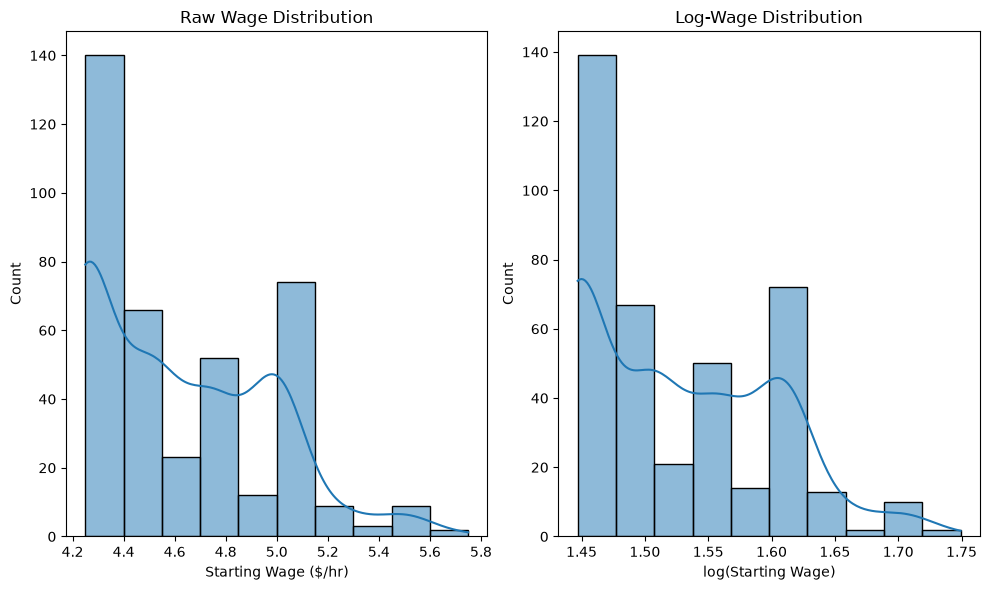

In [19]:
# Visualizing the log-transformation
plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
sns.histplot(df['WAGE_ST'].dropna(), kde=True)
plt.title("Raw Wage Distribution")
plt.xlabel("Starting Wage ($/hr)")

plt.subplot(1, 2, 2)
sns.histplot(np.log(df['WAGE_ST'].dropna()), kde=True)
plt.title("Log-Wage Distribution")
plt.xlabel("log(Starting Wage)")

plt.tight_layout()
plt.show()

## Bivariate Relationship

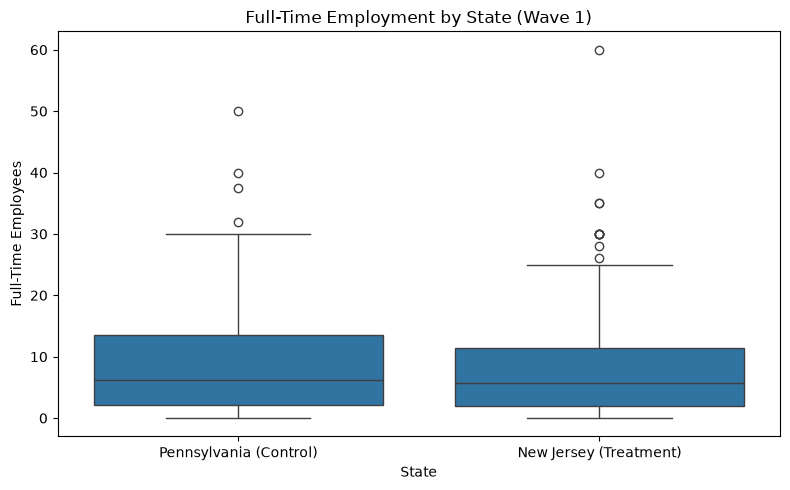

In [20]:
# Binary treatment (STATE) vs full-time employment — box plot
plt.figure(figsize=(8, 5))
sns.boxplot(x='STATE', y='EMPFT', data=df)
plt.xticks([0, 1], ['Pennsylvania (Control)', 'New Jersey (Treatment)'])
plt.title("Full-Time Employment by State (Wave 1)")
plt.xlabel("State")
plt.ylabel("Full-Time Employees")

plt.tight_layout()
plt.show()

## Summary Statistics (Table 1)
Wave 1: all stores except # 407 (includes stores later excluded from the regression panel — valid Wave 1 data)
Wave 2: only STATUS2==1 (excludes closed stores from descriptive stats, matching C&K Table 2)

In [21]:
df_w1 = df[df['SHEET'] != 407].copy()
df_w2 = df_complete[df_complete['STATUS2'] == 1].copy()

# Wave 1 derived variables
df_w1['FTE']    = df_w1['EMPFT'] + 0.5 * df_w1['EMPPT'] + df_w1['NMGRS']
df_w1['FRACFT'] = df_w1['EMPFT'] / df_w1['FTE']
df_w1['PMEAL']  = df_w1['PSODA'] + df_w1['PFRY'] + df_w1['PENTREE']
df_w1['ATMIN']  = (df_w1['WAGE_ST'] == 4.25).astype(float)

# Wave 2 derived variables
df_w2['FTE2']    = df_w2['EMPFT2'] + 0.5 * df_w2['EMPPT2'] + df_w2['NMGRS2']
df_w2['FRACFT2'] = np.where(df_w2['FTE2'] > 0, df_w2['EMPFT2'] / df_w2['FTE2'], np.nan)
df_w2['PMEAL2']  = df_w2['PSODA2'] + df_w2['PFRY2'] + df_w2['PENTREE2']
df_w2['ATMIN2']  = (df_w2['WAGE_ST2'] == 4.25).astype(float)
df_w2['NEWMIN']  = (df_w2['WAGE_ST2'] == 5.05).astype(float)

nj1 = df_w1[df_w1['STATE'] == 1]
pa1 = df_w1[df_w1['STATE'] == 0]
nj2 = df_w2[df_w2['STATE'] == 1]
pa2 = df_w2[df_w2['STATE'] == 0]

def row(nj_vals, pa_vals, pct=False):
    nj_vals = nj_vals.dropna()
    pa_vals = pa_vals.dropna()
    nj_mean = nj_vals.mean() * (100 if pct else 1)
    pa_mean = pa_vals.mean() * (100 if pct else 1)
    se      = np.sqrt(nj_vals.var(ddof=1)/len(nj_vals) + pa_vals.var(ddof=1)/len(pa_vals))
    t_stat  = (nj_vals.mean() - pa_vals.mean()) / se
    return [round(nj_mean, 2), round(pa_mean, 2), round(t_stat, 2)]

store_type_rows = {
    'Burger King':               row((nj1['CHAIN']==1).astype(float), (pa1['CHAIN']==1).astype(float), pct=True),
    'KFC':                       row((nj1['CHAIN']==2).astype(float), (pa1['CHAIN']==2).astype(float), pct=True),
    'Roy Rogers':                row((nj1['CHAIN']==3).astype(float), (pa1['CHAIN']==3).astype(float), pct=True),
    "Wendy's":                   row((nj1['CHAIN']==4).astype(float), (pa1['CHAIN']==4).astype(float), pct=True),
    'Company-owned':             row(nj1['CO_OWNED'],  pa1['CO_OWNED'],  pct=True),
}

wave1_rows = {
    'FTE employment':            row(nj1['FTE'],       pa1['FTE']),
    'Percentage full-time':      row(nj1['FRACFT'],    pa1['FRACFT'],    pct=True),
    'Starting wage':             row(nj1['WAGE_ST'],   pa1['WAGE_ST']),
    'Wage = $4.25 (percentage)': row(nj1['ATMIN'],     pa1['ATMIN'],     pct=True),
    'Price of full meal':        row(nj1['PMEAL'],     pa1['PMEAL']),
    'Hours open (weekday)':      row(nj1['HRSOPEN'],   pa1['HRSOPEN']),
    'Recruiting bonus':          row(nj1['BONUS'],     pa1['BONUS'],     pct=True),
}

wave2_rows = {
    'FTE employment':            row(nj2['FTE2'],      pa2['FTE2']),
    'Percentage full-time':      row(nj2['FRACFT2'],   pa2['FRACFT2'],   pct=True),
    'Starting wage':             row(nj2['WAGE_ST2'],  pa2['WAGE_ST2']),
    'Wage = $4.25 (percentage)': row(nj2['ATMIN2'],    pa2['ATMIN2'],    pct=True),
    'Wage = $5.05 (percentage)': row(nj2['NEWMIN'],    pa2['NEWMIN'],    pct=True),
    'Price of full meal':        row(nj2['PMEAL2'],    pa2['PMEAL2']),
    'Hours open (weekday)':      row(nj2['HRSOPEN2'],  pa2['HRSOPEN2']),
    'Recruiting bonus':          row(nj2['SPECIAL2'],  pa2['SPECIAL2'],  pct=True),
}

table1_types = pd.DataFrame(store_type_rows, index=['NJ', 'PA', 't']).T
table1_wave1 = pd.DataFrame(wave1_rows,      index=['NJ', 'PA', 't']).T
table1_wave2 = pd.DataFrame(wave2_rows,      index=['NJ', 'PA', 't']).T

print("SUMMARY STATISTICS — Distribution of Store Types (%)\n")
print(table1_types.to_string()+"\n")
print("SUMMARY STATISTICS — Wave 1 (Before Minimum Wage Increase)\n")
print(table1_wave1.to_string()+"\n")
print("SUMMARY STATISTICS — Wave 2 (After Minimum Wage Increase)\n")
print(table1_wave2.to_string()+"\n")

SUMMARY STATISTICS — Distribution of Store Types (%)

                  NJ     PA     t
Burger King    41.21  44.87 -0.58
KFC            20.61  14.10  1.43
Roy Rogers     24.85  21.79  0.58
Wendy's        13.33  19.23 -1.21
Company-owned  33.94  34.62 -0.11

SUMMARY STATISTICS — Wave 1 (Before Minimum Wage Increase)

                              NJ     PA     t
FTE employment             20.47  23.49 -2.09
Percentage full-time       32.82  35.26 -0.80
Starting wage               4.61   4.63 -0.44
Wage = $4.25 (percentage)  30.61  33.33 -0.46
Price of full meal          3.35   3.03  4.12
Hours open (weekday)       14.43  14.58 -0.42
Recruiting bonus           23.33  29.49 -1.08

SUMMARY STATISTICS — Wave 2 (After Minimum Wage Increase)

                              NJ     PA      t
FTE employment             21.38  21.58  -0.19
Percentage full-time       35.80  30.67   1.63
Starting wage               5.08   4.62  10.60
Wage = $4.25 (percentage)   0.00  24.68  -4.99
Wage = $5.05 (perc

# 3. Results

## Baseline DiD Model (First Differences, OLS with HC3 Robust Standard Errors)

ΔFTE = B₀ + B₁(STATE) + ε

The coefficient of interest is STATE (B₁)

Each store is differenced against itself, so this is Card & Krueger (1994) equation (1a): one row
per store, with the change in FTE between the two waves as the dependent variable. Any
time-invariant store characteristic cancels out in the difference — the pre-existing NJ–PA level
gap and the common POST time shift are absorbed and no longer appear as separate terms.

With all else equal, STATE captures the employment effect of the NJ minimum wage increase.


In [22]:
# Difference in Differences regression on the first-differenced sample
formula_did = 'DFTE ~ STATE'

model_did = smf.ols(formula=formula_did, data=df_fd).fit(cov_type='HC3', use_t=True)
print(model_did.summary())


                            OLS Regression Results                            
Dep. Variable:                   DFTE   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     4.120
Date:                Sat, 19 Sep 2026   Prob (F-statistic):             0.0431
Time:                        22:49:32   Log-Likelihood:                -1379.9
No. Observations:                 382   AIC:                             2764.
Df Residuals:                     380   BIC:                             2772.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.3142      1.279     -1.810      0.0

#### Interpreting the Coefficient (Ceteris Paribus):

The coefficient we care about here is STATE, which is now the Difference in Differences estimator
directly — there is no interaction term left to read, because each store has been differenced
against itself.

The intercept, -2.3142, is the average change in FTE employment for a PA store: control-state
restaurants shed about 2.3 full-time equivalents between the two waves. STATE, 2.7743, is the
NJ–PA difference in those changes. With all else equal, the minimum wage increase seen in NJ and
not in PA leads to an increase in Full-Time Employment of 2.7743, or about ~3 employees. Against
the Wave 1 NJ baseline of roughly 20.4 FTE, that is a ~13% increase in headcount for fast food
restaurants in NJ from the wage hike.

The pre-existing NJ–PA level difference and the common POST time effect are absorbed by the
differencing and no longer appear as separate terms.


## Heterogeneity Tests

### Sensitivity by Chain

In [23]:
# Checking if different chains felt the effect of the hike to differing levels
formula_interact_chain = 'DFTE ~ STATE + C(CHAIN)'

model_interact_chain = smf.ols(formula=formula_interact_chain, data=df_fd).fit(cov_type='HC3', use_t=True)
print(model_interact_chain.summary())


                            OLS Regression Results                            
Dep. Variable:                   DFTE   R-squared:                       0.029
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     3.226
Date:                Sat, 19 Sep 2026   Prob (F-statistic):             0.0127
Time:                        22:49:32   Log-Likelihood:                -1377.2
No. Observations:                 382   AIC:                             2764.
Df Residuals:                     377   BIC:                             2784.
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        -1.7765      1.529     -1.162

### Corporate vs. Franchisees

In [24]:
# Checking if Corporate vs Franchisees differ in impact
# Hypothesis: franchisees operate on thinner margins = more sensitive to wage increases

formula_interact_co_owned = 'DFTE ~ STATE + STATE:CO_OWNED'

model_interact_co_owned = smf.ols(formula=formula_interact_co_owned, data=df_fd).fit(cov_type='HC3', use_t=True)
print(model_interact_co_owned.summary())


                            OLS Regression Results                            
Dep. Variable:                   DFTE   R-squared:                       0.016
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     2.282
Date:                Sat, 19 Sep 2026   Prob (F-statistic):              0.104
Time:                        22:49:32   Log-Likelihood:                -1379.7
No. Observations:                 382   AIC:                             2765.
Df Residuals:                     379   BIC:                             2777.
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -2.3142      1.279     -1.

### Region of New Jersey

In [25]:
# Shore region may be affected by seasonal patterns not present elsewhere
formula_interact_shore = 'DFTE ~ STATE + STATE:SHORE'

model_interact_shore = smf.ols(formula=formula_interact_shore, data=df_fd).fit(cov_type='HC3', use_t=True)
print(model_interact_shore.summary())


                            OLS Regression Results                            
Dep. Variable:                   DFTE   R-squared:                       0.019
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     2.856
Date:                Sat, 19 Sep 2026   Prob (F-statistic):             0.0588
Time:                        22:49:32   Log-Likelihood:                -1379.1
No. Observations:                 382   AIC:                             2764.
Df Residuals:                     379   BIC:                             2776.
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -2.3142      1.279     -1.810      

# 4. Robustness Checks

### Outlier Detection (Tukey Fence)

Testing whether extreme employment values drive the DiD result.

In [26]:
# Manual Tukey Fence implementation (Wave 1)
Q1_w1 = df_complete['FTE'].quantile(0.25)
Q3_w1 = df_complete['FTE'].quantile(0.75)

IQR_w1 = Q3_w1 - Q1_w1

outliers_w1 = df_complete[(df_complete['FTE'] < (Q1_w1 - 1.5 * IQR_w1)) | (df_complete['FTE'] > (Q3_w1 + 1.5 * IQR_w1))]

print(f'Q1: {Q1_w1},  Q3: {Q3_w1},  IQR: {IQR_w1}')
print(f'Lower fence: {Q1_w1 - 1.5 * IQR_w1:.2f},  Upper fence: {Q3_w1 + 1.5 * IQR_w1:.2f}')
print(f'Outliers detected: {len(outliers_w1)} stores')
outliers_w1[['SHEET','STATE','FTE','EMPPT','NMGRS','WAGE_ST']]

Q1: 15.0,  Q3: 24.5,  IQR: 9.5
Lower fence: 0.75,  Upper fence: 38.75
Outliers detected: 18 stores


,SHEET,STATE,FTE,EMPPT,NMGRS,WAGE_ST
0,46,0,40.5,15.0,3.0,NaN
6,445,0,70.5,35.0,3.0,5.00
11,468,0,58.0,30.0,3.0,5.00
43,432,0,52.5,55.0,5.0,4.50
45,434,0,45.0,50.0,5.0,4.25
59,471,0,39.0,20.0,4.0,4.25
60,472,0,41.5,2.0,3.0,4.25
65,478,0,48.5,25.0,4.0,4.50
85,191,1,44.0,20.0,4.0,NaN
98,26,1,41.5,15.0,4.0,5.56


In [27]:
# Manual Tukey Fence — Wave 2
Q1_w2 = df_complete['FTE2'].quantile(0.25)
Q3_w2 = df_complete['FTE2'].quantile(0.75)

IQR_w2 = Q3_w2 - Q1_w2

outliers_w2 = df_complete[(df_complete['FTE2'] < (Q1_w2 - 1.5 * IQR_w2)) | (df_complete['FTE2'] > (Q3_w2 + 1.5 * IQR_w2))]

print(f'Wave 2 — Q1: {Q1_w2},  Q3: {Q3_w2},  IQR: {IQR_w2}')
print(f'Lower fence: {Q1_w2 - 1.5 * IQR_w2:.2f},  Upper fence: {Q3_w2 + 1.5 * IQR_w2:.2f}')
print(f'Outliers detected: {len(outliers_w2)} stores')
outliers_w2[['SHEET','STATE','FTE2','EMPPT2','NMGRS2','WAGE_ST2']]

Wave 2 — Q1: 14.5,  Q3: 26.5,  IQR: 12.0
Lower fence: -3.50,  Upper fence: 44.50
Outliers detected: 6 stores


,SHEET,STATE,FTE2,EMPPT2,NMGRS2,WAGE_ST2
92,311,1,53.0,30.0,3.0,5.05
95,372,1,45.0,20.0,5.0,5.05
152,324,1,46.5,39.0,5.0,5.05
220,99,1,59.0,50.0,4.0,5.05
246,142,1,60.5,31.0,5.0,5.05
320,267,1,47.5,25.0,5.0,5.05


In [28]:
# Tukey fence on starting wage
Q1_w = df_complete['WAGE_ST'].quantile(0.25)
Q3_w = df_complete['WAGE_ST'].quantile(0.75)
IQR_w = Q3_w - Q1_w

print(df_complete['WAGE_ST'].describe())
print(f'Fences: {Q1_w - 1.5*IQR_w:.2f} to {Q3_w + 1.5*IQR_w:.2f}')
print(f'Flagged: {((df_complete["WAGE_ST"] < Q1_w - 1.5*IQR_w) | (df_complete["WAGE_ST"] > Q3_w + 1.5*IQR_w)).sum()}')

count    383.000000
mean       4.611436
std        0.341858
min        4.250000
25%        4.250000
50%        4.500000
75%        4.950000
max        5.620000
Name: WAGE_ST, dtype: float64
Fences: 3.20 to 6.00
Flagged: 0


In [29]:
# Get SHEET numbers of outliers identified by Tukey fence
outlier_sheets = pd.concat([
    outliers_w1[['SHEET']],
    outliers_w2[['SHEET']]
])['SHEET'].unique()

# Filter the first-differenced frame built from the balanced sample
df_fd_no_outliers = df_fd[~df_fd['SHEET'].isin(outlier_sheets)].copy()

print(f'Stores removed: {len(outlier_sheets)}')
print(f'Stores remaining: {len(df_fd_no_outliers)}')
print(f'Missing DFTE rows: {df_fd_no_outliers["DFTE"].isnull().sum()}')

# Rerun baseline DiD without outliers
model_did_no_outliers = smf.ols('DFTE ~ STATE',
                                 data=df_fd_no_outliers).fit(cov_type='HC3', use_t=True)
print(model_did_no_outliers.summary())


Stores removed: 22
Stores remaining: 360
Missing DFTE rows: 0
                            OLS Regression Results                            
Dep. Variable:                   DFTE   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.6465
Date:                Sat, 19 Sep 2026   Prob (F-statistic):              0.422
Time:                        22:49:32   Log-Likelihood:                -1225.2
No. Observations:                 360   AIC:                             2454.
Df Residuals:                     358   BIC:                             2462.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

In [30]:
# Pre-treatment trim only
outlier_sheets_w1 = outliers_w1['SHEET'].unique()
df_fd_w1_trim = df_fd[~df_fd['SHEET'].isin(outlier_sheets_w1)].copy()

print(f'Stores removed: {len(outlier_sheets_w1)}')
print(f'Stores remaining: {len(df_fd_w1_trim)}')

model_w1_trim = smf.ols('DFTE ~ STATE',
                        data=df_fd_w1_trim).fit(cov_type='HC3', use_t=True)
print(model_w1_trim.summary())


Stores removed: 18
Stores remaining: 364
                            OLS Regression Results                            
Dep. Variable:                   DFTE   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.177
Date:                Sat, 19 Sep 2026   Prob (F-statistic):              0.279
Time:                        22:49:32   Log-Likelihood:                -1260.2
No. Observations:                 364   AIC:                             2524.
Df Residuals:                     362   BIC:                             2532.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  

In [31]:
# First-differenced frame using only STATUS2==1 stores (no closed stores set to 0)
df_no_closed = df_complete[df_complete['STATUS2'] == 1].copy()

df_fd_no_closed = df_no_closed[['SHEET', 'STATE', 'CHAIN', 'CO_OWNED', 'SHORE', 'GAP']].copy()
df_fd_no_closed['fte_1'] = df_no_closed['FTE']
df_fd_no_closed['fte_2'] = df_no_closed['FTE2']
df_fd_no_closed['DFTE']  = df_fd_no_closed['fte_2'] - df_fd_no_closed['fte_1']

print(f'Missing DFTE rows: {df_fd_no_closed["DFTE"].isnull().sum()}')

# Same balanced-sample rule as the main frame -- a store needs both waves to be differenced
missing_nc = df_fd_no_closed.loc[df_fd_no_closed['DFTE'].isnull(), 'SHEET'].unique()
df_fd_no_closed = df_fd_no_closed.dropna(subset=['DFTE']).copy()

print(f'Stores dropped: {len(missing_nc)}')
print(f'Stores remaining: {len(df_fd_no_closed)}')

model_did_no_closed = smf.ols('DFTE ~ STATE',
                               data=df_fd_no_closed).fit(cov_type='HC3', use_t=True)
print(model_did_no_closed.summary())


Missing DFTE rows: 21
Stores dropped: 21
Stores remaining: 376
                            OLS Regression Results                            
Dep. Variable:                   DFTE   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     4.042
Date:                Sat, 19 Sep 2026   Prob (F-statistic):             0.0451
Time:                        22:49:32   Log-Likelihood:                -1355.3
No. Observations:                 376   AIC:                             2715.
Df Residuals:                     374   BIC:                             2723.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------

## Treatment Intensity (GAP Regression)
Tests whether stores that had to raise wages more saw larger employment effects.
Run on the full sample, matching Card & Krueger -- PA stores all carry GAP = 0.

In [32]:
# Full sample -- GAP is already 0 for every PA store
df_gap = df_complete.copy()

# Compute change in employment
df_gap['DFTE'] = df_gap['FTE2'] - df_gap['FTE']

print(f'Missing DFTE rows: {df_gap["DFTE"].isnull().sum()}')
print(f'GAP sample: {df_gap["DFTE"].notna().sum()} stores')

df_gap = df_gap.dropna(subset=['DFTE'])

# Baseline: does GAP predict employment change?
formula_gap = 'DFTE ~ GAP'
model_gap = smf.ols(formula=formula_gap, data=df_gap).fit(cov_type='HC3', use_t=True)
print(model_gap.summary())

# With controls
formula_gap_controls = 'DFTE ~ GAP + CO_OWNED + C(CHAIN)'
model_gap_controls = smf.ols(formula=formula_gap_controls, data=df_gap).fit(cov_type='HC3', use_t=True)
print(model_gap_controls.summary())

# Validity test from the original paper -- STATE dummy alongside GAP
formula_gap_state = 'DFTE ~ GAP + STATE'
model_gap_state = smf.ols(formula=formula_gap_state, data=df_gap).fit(cov_type='HC3', use_t=True)
print(model_gap_state.summary())


Missing DFTE rows: 21
GAP sample: 382 stores
                            OLS Regression Results                            
Dep. Variable:                   DFTE   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     4.331
Date:                Sat, 19 Sep 2026   Prob (F-statistic):             0.0381
Time:                        22:49:32   Log-Likelihood:                -1380.6
No. Observations:                 382   AIC:                             2765.
Df Residuals:                     380   BIC:                             2773.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Interce

In [33]:
# Part-time share of headcount, by wave (check for management shifting employees to part-time to avoid the wage hike)
df_pt = df_complete[df_complete['STATUS2'] == 1].copy()

df_pt['PT_SHARE_1'] = df_pt['EMPPT'] / (df_pt['EMPFT'] + df_pt['EMPPT'])
df_pt['PT_SHARE_2'] = df_pt['EMPPT2'] / (df_pt['EMPFT2'] + df_pt['EMPPT2'])
df_pt['D_PT_SHARE'] = df_pt['PT_SHARE_2'] - df_pt['PT_SHARE_1']

print(df_pt.groupby('STATE')[['PT_SHARE_1', 'PT_SHARE_2', 'D_PT_SHARE']].mean())
print()
print(df_pt.groupby('STATE')['D_PT_SHARE'].describe()[['count', 'mean', 'std']])

# Formal test: did NJ shift part-time more than PA?
model_pt = smf.ols('D_PT_SHARE ~ STATE', data=df_pt.dropna(subset=['D_PT_SHARE'])).fit(cov_type='HC3', use_t=True)
print(model_pt.summary())

       PT_SHARE_1  PT_SHARE_2  D_PT_SHARE
STATE                                    
0         0.69278    0.737248    0.046266
1         0.70979    0.680541   -0.030780

       count      mean       std
STATE                           
0       74.0  0.046266  0.340530
1      309.0 -0.030780  0.305689
                            OLS Regression Results                            
Dep. Variable:             D_PT_SHARE   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     3.138
Date:                Sat, 19 Sep 2026   Prob (F-statistic):             0.0773
Time:                        22:49:32   Log-Likelihood:                -97.166
No. Observations:                 383   AIC:                             198.3
Df Residuals:                     381   BIC:                             206.2
Df Model:                           1                              

# 5. Table Exports

## Table 1 -- Summary Statistics

In [34]:
# Adds subtitle labels so each section can be properly read in Word
def labeled_section(title, table):
    header = pd.DataFrame([['', '', '']], columns=['NJ', 'PA', 't'], index=[title])
    spacer = pd.DataFrame([['', '', '']], columns=['NJ', 'PA', 't'], index=[''])
    return pd.concat([header, table, spacer])

# Concat all three sections into one table for the paper
combined = pd.concat([
    labeled_section('Store Type Distribution (%)',       table1_types),
    labeled_section('Wave 1 — Before Minimum Wage Increase', table1_wave1),
    labeled_section('Wave 2 — After Minimum Wage Increase',  table1_wave2),
])

combined.to_html('summary_stats.html')


## Table 2 -- DiD Regression

In [35]:
from statsmodels.iolib.summary2 import summary_col

table2 = summary_col(
    [model_did, model_interact_chain, model_interact_co_owned, model_interact_shore],
    model_names=['Baseline (1a)', 'Chain (1b)', 'Ownership (1c)', 'Shore (1d)'],
    stars=True,
    float_format='%0.3f',
    regressor_order=['STATE'],
    info_dict={'N': lambda x: f'{int(x.nobs)}'})

with open('regression_table.html', 'w') as f:
    f.write(table2.as_html())


## DAG

In [36]:
dag = """
State (NJ=1, PA=0) ──────────────────────────> FTE Employment
        │                                            ^
        │                                            │
        V                                            │
Minimum Wage Hike ────────────────────────────────────|
        ^
        │
Time (POST=1) ─────────────────────────────────────> FTE Employment
"""

print(dag)


State (NJ=1, PA=0) ──────────────────────────> FTE Employment
        │                                            ^
        │                                            │
        V                                            │
Minimum Wage Hike ────────────────────────────────────|
        ^
        │
Time (POST=1) ─────────────────────────────────────> FTE Employment

